<a href="https://colab.research.google.com/github/yoh6ly/Yohaly/blob/main/prediccion_desempleo_carreras_2034.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_d

Precisión: 0.0
Recall: 0.0
F1-score: 0.0
MSE: 0.0

Reporte de clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



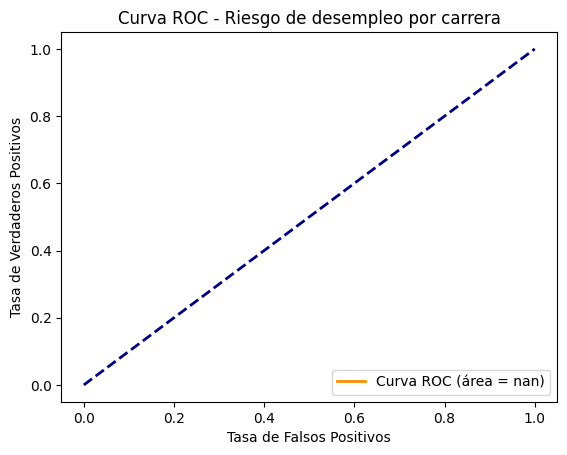

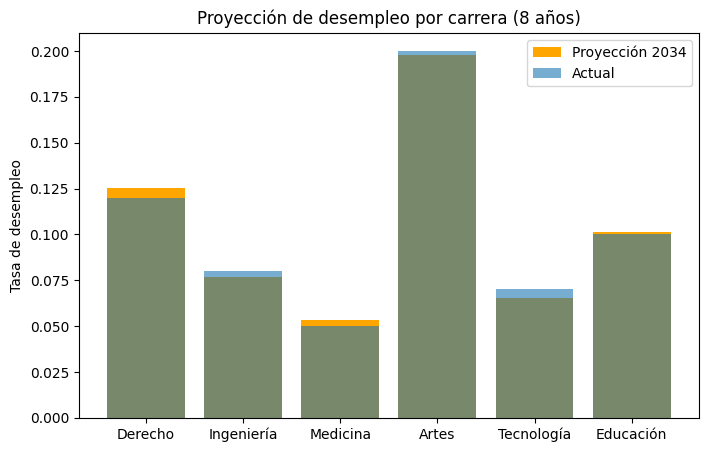

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score, mean_squared_error, classification_report
from sklearn.model_selection import train_test_split

# 1. Datos ficticios: carreras, estudiantes, demanda laboral y desempleo actual
data = {
    "Carrera": ["Derecho", "Ingeniería", "Medicina", "Artes", "Tecnología", "Educación"],
    "Estudiantes": [12000, 15000, 8000, 2000, 10000, 5000],
    "Demanda_laboral": [0.6, 0.8, 0.9, 0.3, 0.85, 0.7],
    "Desempleo_actual": [0.12, 0.08, 0.05, 0.20, 0.07, 0.10]
}
df = pd.DataFrame(data)

# 2. Modelo de regresión para proyectar desempleo a 8 años
X = df[["Estudiantes", "Demanda_laboral"]]
y = df["Desempleo_actual"]

reg_model = LinearRegression()
reg_model.fit(X, y)

# Proyección futura (+20% estudiantes, demanda constante)
futuro_estudiantes = df["Estudiantes"] * 1.2
futuro_demanda = df["Demanda_laboral"]
X_futuro = np.column_stack((futuro_estudiantes, futuro_demanda))
df["Desempleo_proyectado_2034"] = reg_model.predict(X_futuro)

# 3. Clasificación binaria: riesgo alto de desempleo (>0.12)
y_bin = (df["Desempleo_actual"] > 0.12).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.3, random_state=42)

clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_score = clf.predict_proba(X_test)[:,1]

# 4. Métricas de evaluación
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Precisión:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("MSE:", mse)
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

# 5. Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Riesgo de desempleo por carrera')
plt.legend(loc="lower right")
plt.show()

# 6. Visualización comparativa
plt.figure(figsize=(8,5))
plt.bar(df["Carrera"], df["Desempleo_proyectado_2034"], color="orange", label="Proyección 2034")
plt.bar(df["Carrera"], df["Desempleo_actual"], alpha=0.6, label="Actual")
plt.ylabel("Tasa de desempleo")
plt.title("Proyección de desempleo por carrera (8 años)")
plt.legend()
plt.show()